# Boosting

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Example 1

In [2]:
m = 100
x = (np.random.uniform(0,10,m))
y = (5*x + 1 + np.random.randn(m))

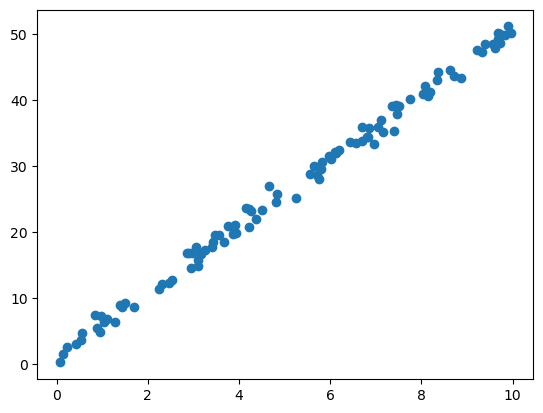

In [3]:
plt.scatter(x,y)

In [4]:
from sklearn.tree import DecisionTreeRegressor

In [5]:
x=x.reshape(-1,1)

In [6]:
# decision trees 

tree_reg1 = DecisionTreeRegressor(max_depth = 2)
tree_reg1.fit(x,y)


DecisionTreeRegressor(max_depth=2)

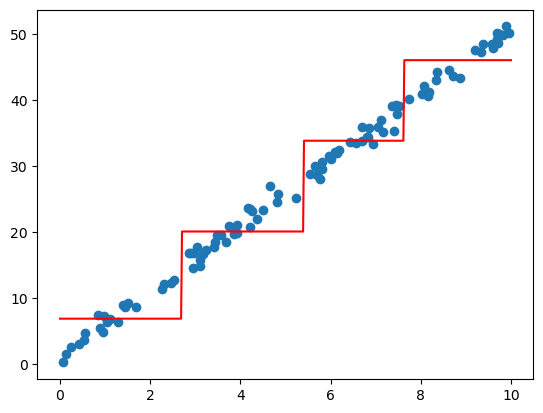

In [7]:
# plot data + fitted model
plt.scatter(x,y)
x_plot = np.linspace(0,10,500).reshape(500,1)
y_plot = tree_reg1.predict(x_plot)
plt.plot(x_plot,y_plot,color='red')

In [8]:
# tree number 2: predictions

yhat = tree_reg1.predict(x)
# residuals (errors)
y1 = y - yhat
# fit next tree to the residuals
tree_reg2=DecisionTreeRegressor(max_depth=2)

In [9]:
tree_reg2.fit(x,y1)

DecisionTreeRegressor(max_depth=2)

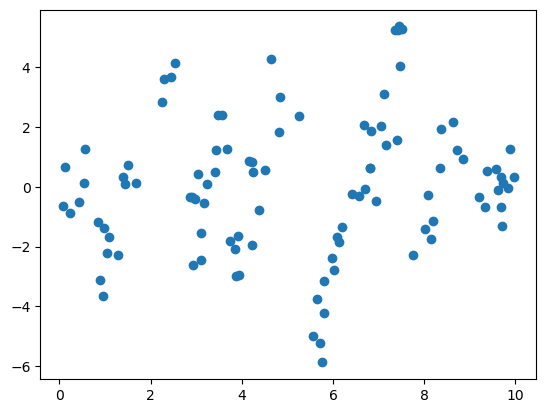

In [10]:
# new predictions
yhat1 = tree_reg2.predict(x)
# residuals
y2 = y1-yhat1
# fit tree 3
tree_reg3 = DecisionTreeRegressor(max_depth=2)
tree_reg3.fit(x,y2)
# tree 3 predictions
yhat2 = tree_reg3.predict(x)
# residuals
y3 = y2-yhat2

# fit tree 4
tree_reg4 = DecisionTreeRegressor(max_depth=2)
tree_reg4.fit(x,y3)
# tree 4 predictions
yhat3 = tree_reg4.predict(x)
# residuals
y4 = y3-yhat3

# fit tree 5
tree_reg5 = DecisionTreeRegressor(max_depth=2)
tree_reg5.fit(x,y4)
# tree 5 predictions
yhat4 = tree_reg5.predict(x)
# residuals
y5 = y4-yhat4



plt.scatter(x,y4)

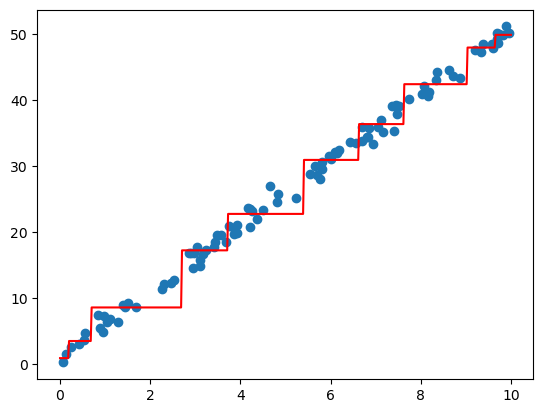

In [11]:
# plot final model
y1_plot = tree_reg1.predict(x_plot)
y2_plot = tree_reg2.predict(x_plot)
y3_plot = tree_reg3.predict(x_plot)
y4_plot = tree_reg4.predict(x_plot)
y5_plot = tree_reg5.predict(x_plot)

y_plot = y1_plot + y2_plot + y3_plot +y4_plot + y5_plot
plt.scatter(x,y)
plt.plot(x_plot,y_plot,color='red')

## Example 2

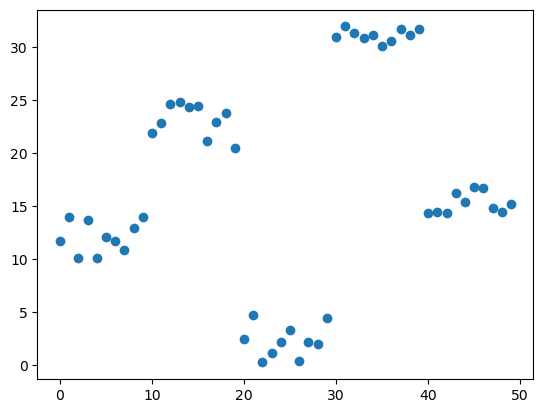

In [12]:
x = np.arange(50)
y1 = np.random.uniform(10,15,10)
y2 = np.random.uniform(20,25,10)
y3 = np.random.uniform(0,5,10)
y4 = np.random.uniform(30,32,10)
y5 = np.random.uniform(13,17,10)

y = np.concatenate((y1,y2,y3,y4,y5))
plt.scatter(x,y)

In [13]:
x = x.reshape(50,1)
r = y.copy()

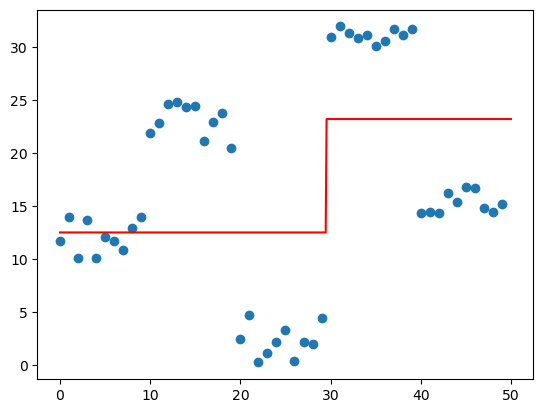

In [14]:
# initial tree
tree_reg = DecisionTreeRegressor(max_depth=1)
tree_reg.fit(x,y)
#predictions
y_pred = tree_reg.predict(x)
# plot initial tree
x_plot = np.linspace(0,50,500).reshape(500,1)
y_plot = tree_reg.predict(x_plot)

plt.scatter(x,y)
plt.plot(x_plot,y_plot,color='red')

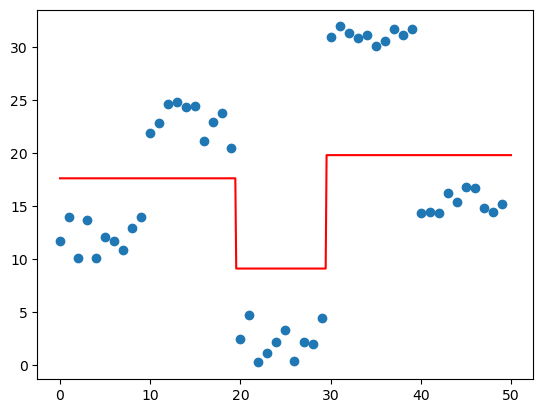

In [15]:
# residuals
r = r - tree_reg.predict(x)
#next tree
tree_reg = DecisionTreeRegressor(max_depth=1)
# fit tree to the residuals
tree_reg.fit(x,r)
# predictions
y_pred += tree_reg.predict(x)
y_plot+=tree_reg.predict(x_plot)
# plot data + fitted model
plt.scatter(x,y)
plt.plot(x_plot,y_plot,color='red')

## Building a boosting model in scikit-learn

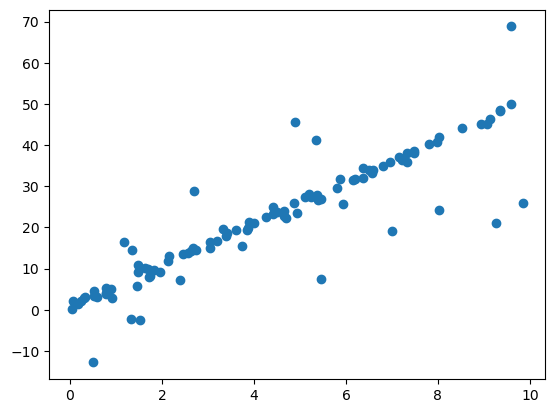

In [23]:
m = 100
x = np.random.uniform(0,10,m).reshape(100,1)
y = 5*x+1+np.random.randn(m).reshape(100,1)
# add outliers
y[::5] += 50*(0.5-np.random.rand(20)).reshape(20,1)

plt.scatter(x,y)

In [19]:
from sklearn.ensemble import GradientBoostingRegressor

Boosting methods are quick to overfit the training data

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/ensemble/_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


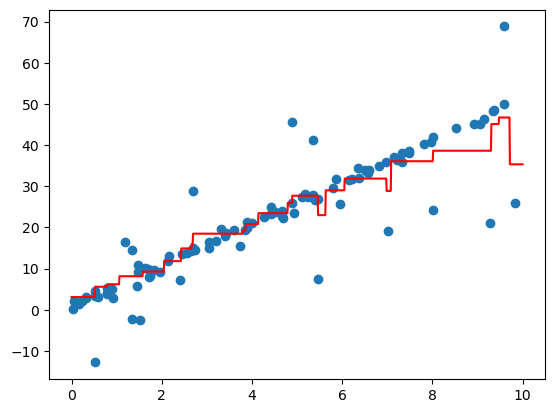

In [32]:
gb_reg = GradientBoostingRegressor(n_estimators=10, # number of trees
                                  max_depth = 2, # depth of trees
                                  learning_rate=0.25,
                                  )

                                  
gb_reg.fit(x,y)
x_plot = np.linspace(0,10,1000).reshape(1000,1)
y_plot = gb_reg.predict(x_plot)

plt.scatter(x,y)
plt.plot(x_plot,y_plot,color='red')